# Calendario Escolar, Franjas Horarias y Paneles de Análisis
## De las series horarias imputadas a los paneles del estudio

Este notebook toma las series horarias imputadas del notebook 00 (las dos vías:
híbrida y MIMA) y el calendario oficial de la SEP, y construye los insumos de todo
el análisis: los agregados por franja horaria, el panel día-zona de la franja pico
y el panel de brechas entre franjas.

Las franjas se definen así y por esto:
- **Franja pico (07:00-09:00)**: la ventana de ENTRADA escolar. Los horarios de
  educación básica en México concentran la llegada de alumnos entre 7:30 y 8:00
  (matutino), así que el tráfico de entrada vive en estas dos horas.
- **Franja control (10:00-12:00)**: media mañana del MISMO día. Para las 10 el
  tráfico de entrada ya terminó, pero el día sigue siendo el mismo: mismo clima,
  misma temporada, mismos eventos. Esa cercanía es la que vuelve a esta franja un
  pseudo-control interno: una aproximación a la misma mañana sin tráfico de entrada,
  no un control exacto (la meteorología evoluciona dentro de la mañana).
- Cada franja se resume como el promedio de sus horas (los sellos horarios 07 y 08
  cubren 07:00-09:00; los sellos 10 y 11 cubren 10:00-12:00).

**Data access / Acceso a los datos.** The SIMA measurements used here are not
redistributed in this repository (SIMA provided them for this study on the condition
that they are not disseminated); the repository holds the code, the official school
calendar and all derived results. This notebook reads files that notebooks 00 and 01
build from those measurements, and its configuration cell stops with a clear message
if they are missing. To rebuild them, request the annual workbooks from SIMA, place
them in `data_raw/` and run notebook 00 (its header gives the exact file format). /
Las mediciones de SIMA no se redistribuyen en este repositorio (SIMA las entregó para
este estudio con la condición de no difundirlas); el repositorio contiene el código, el
calendario oficial y todos los resultados derivados. Este notebook lee archivos que los
notebooks 00 y 01 construyen a partir de esas mediciones, y su celda de configuración
se detiene con un mensaje claro si faltan. Para reconstruirlos, solicite los libros
anuales a SIMA, colóquelos en `data_raw/` y corra el notebook 00 (su encabezado da el
formato exacto).

**Role in the analysis / Papel en el análisis.** Data preparation: the time windows, the day–zone panels and the within-day gaps that every later notebook uses. / Preparación de datos: las ventanas, los paneles día-zona y las brechas dentro del día que usan todos los notebooks siguientes. The analytical hierarchy of the whole repository is stated in the README. / La jerarquía analítica de todo el repositorio está en el README.

## 1. Configuración inicial

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilo
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

contaminantes = ['CO', 'NO2', 'O3', 'PM10', 'PM2.5']

output_dir = Path('../data_processed')
graficos_dir = output_dir / 'calendario'
graficos_dir.mkdir(exist_ok=True)

print("Librerías importadas exitosamente")

# Verificación de los datos de entrada (no se redistribuyen; ver la nota del encabezado)
# / Input data check (not redistributed; see the note in the header)
archivos_requeridos = [output_dir / 'datos_horarios_imputados_hibrido.csv.gz',
                       output_dir / 'datos_horarios_imputados_MIMA.csv.gz',
                       output_dir / 'calendario_oficial_sep.csv']
faltantes = [str(a) for a in archivos_requeridos if not a.exists()]
if faltantes:
    raise FileNotFoundError(
        "Faltan archivos derivados de las mediciones de SIMA, que no se redistribuyen en este repositorio. "
        "Solicite los libros anuales a SIMA, colóquelos en data_raw/ y corra los notebooks 00 y 01. / "
        "Files derived from the SIMA measurements are missing; they are not redistributed in this repository. "
        "Request the annual workbooks from SIMA, place them in data_raw/ and run notebooks 00 and 01. "
        f"Faltantes / missing: {faltantes}")
print(f"Datos de entrada encontrados / input data found: {len(archivos_requeridos)} archivos")

Librerías importadas exitosamente
Datos de entrada encontrados / input data found: 3 archivos


## 2. Carga de insumos y construcción de los agregados por franja

Los agregados día-zona-franja se construyen aquí, directamente de las series
horarias imputadas del notebook 00.

In [2]:
calendario = pd.read_csv('../data_processed/calendario_oficial_sep.csv', parse_dates=['date'])

horas_franja = {'pico_7_9': [7, 8], 'fuera_pico_10_12': [10, 11]}

def construir_agregados(ruta_horaria, nombre_dataset):
    """
    Promedio por (día, zona, franja, contaminante) desde la serie horaria imputada.
    """
    horario = pd.read_csv(ruta_horaria, parse_dates=['date'])
    horario['fecha'] = horario['date'].dt.normalize()
    horario['hora'] = horario['date'].dt.hour
    piezas = []
    for franja, horas in horas_franja.items():
        sub_f = horario[horario['hora'].isin(horas)]
        agregado = (sub_f.groupby(['fecha', 'estacion', 'parametro'])['valor'].mean()
                    .unstack('parametro').reset_index()
                    .rename(columns={'fecha': 'date'}))
        agregado['franja_horaria'] = franja
        piezas.append(agregado)
    salida = pd.concat(piezas, ignore_index=True)
    print(f"[{nombre_dataset}] agregados: {len(salida):,} filas "
          f"({salida['date'].nunique()} días x {salida['estacion'].nunique()} zonas x 2 franjas)")
    return salida

df_hibrido = construir_agregados('../data_processed/datos_horarios_imputados_hibrido.csv.gz', 'hibrido')
df_mima = construir_agregados('../data_processed/datos_horarios_imputados_MIMA.csv.gz', 'MIMA')

print("=" * 70)
print("INSUMOS LISTOS")
print("=" * 70)
print(f"Calendario oficial: {len(calendario)} días | lectivos: {int(calendario['lectivo'].sum())} | "
      f"días efectivos de clase: {int(calendario['dia_clases'].sum())}")
print(f"Zonas de monitoreo: {sorted(df_hibrido['estacion'].unique())}")

[hibrido] agregados: 13,152 filas (1096 días x 6 zonas x 2 franjas)


[MIMA] agregados: 13,152 filas (1096 días x 6 zonas x 2 franjas)
INSUMOS LISTOS
Calendario oficial: 1096 días | lectivos: 884 | días efectivos de clase: 607
Zonas de monitoreo: ['CENTRO', 'NORESTE3', 'NOROESTE3', 'NORTE2', 'SUR', 'SUROESTE2']


## 3. Cortes del calendario para los análisis de series de tiempo

Los cortes principales son las fechas de REGRESO DE ALUMNOS (con fuente, notebook 00);
los cortes de referencia (falsación) son los puntos medios de las vacaciones largas
oficiales, donde no debería haber ningún salto. El receso de invierno 2025-26 empieza
al final de la ventana y no tiene periodo posterior, así que no entra como corte.

In [3]:
inicios_alumnos = ['2023-01-09', '2023-08-28', '2024-01-08', '2024-08-26', '2025-01-09',
                   '2025-09-01']

vacaciones_largas = [('2023-07-27', '2023-08-27'),   # verano 2023
                     ('2023-12-18', '2024-01-05'),   # invierno 2023-24
                     ('2024-03-25', '2024-04-05'),   # semana santa 2024
                     ('2024-07-17', '2024-08-25'),   # verano 2024
                     ('2024-12-19', '2025-01-08'),   # invierno 2024-25
                     ('2025-07-17', '2025-08-31')]   # verano 2025
cortes_placebo = []
for inicio, fin in vacaciones_largas:
    medio = pd.Timestamp(inicio) + (pd.Timestamp(fin) - pd.Timestamp(inicio)) / 2
    cortes_placebo.append(str(medio.normalize().date()))

pd.DataFrame({'inicio_clases': pd.to_datetime(inicios_alumnos)}).to_csv(
    output_dir / 'inicios_bloques_clase.csv', index=False)
pd.DataFrame({'corte_placebo': pd.to_datetime(cortes_placebo)}).to_csv(
    output_dir / 'cortes_placebo.csv', index=False)

print("=" * 70)
print("CORTES DEFINIDOS")
print("=" * 70)
print(f"Inicios (regreso de alumnos): {inicios_alumnos}")
print(f"Cortes de referencia (medios de vacaciones): {cortes_placebo}")
print(f"Guardado en: {output_dir / 'inicios_bloques_clase.csv'} y {output_dir / 'cortes_placebo.csv'}")

CORTES DEFINIDOS
Inicios (regreso de alumnos): ['2023-01-09', '2023-08-28', '2024-01-08', '2024-08-26', '2025-01-09', '2025-09-01']
Cortes de referencia (medios de vacaciones): ['2023-08-11', '2023-12-27', '2024-03-30', '2024-08-05', '2024-12-29', '2025-08-08']
Guardado en: ../data_processed/inicios_bloques_clase.csv y ../data_processed/cortes_placebo.csv


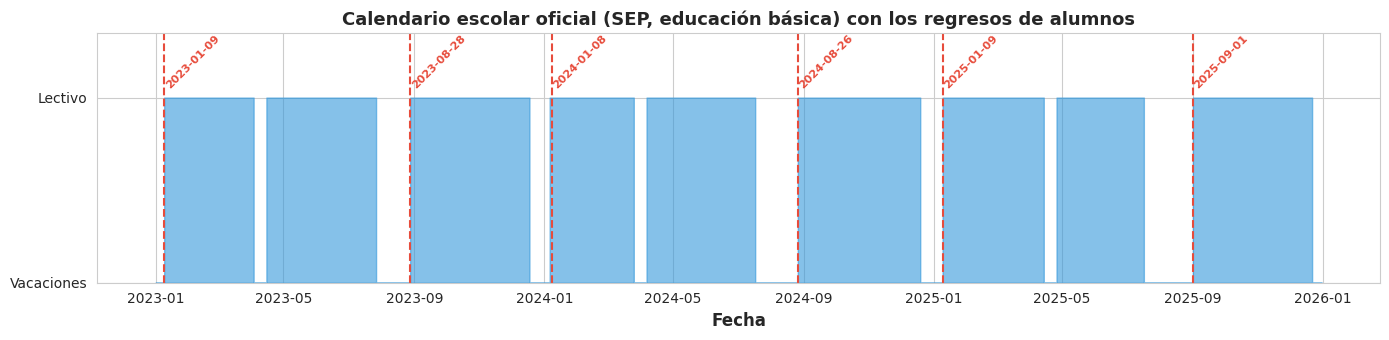

Guardado gráfico en: ../data_processed/calendario/02_calendario_oficial_timeline.png


In [4]:
fig, ax = plt.subplots(figsize=(14, 3.5))

serie_lectivo = calendario.set_index('date')['lectivo']
ax.fill_between(serie_lectivo.index, 0, serie_lectivo.values, step='post',
                color='#3498db', alpha=0.6, label='Periodo lectivo (oficial SEP)')
for inicio in inicios_alumnos:
    t = pd.Timestamp(inicio)
    ax.axvline(t, color='#e74c3c', linestyle='--', linewidth=1.5)
    ax.text(t, 1.05, inicio, rotation=45, fontsize=8, ha='left', color='#e74c3c', fontweight='bold')

ax.set_ylim(0, 1.35)
ax.set_yticks([0, 1])
ax.set_yticklabels(['Vacaciones', 'Lectivo'])
ax.set_xlabel('Fecha', fontsize=12, fontweight='bold')
ax.set_title('Calendario escolar oficial (SEP, educación básica) con los regresos de alumnos',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(graficos_dir / '02_calendario_oficial_timeline.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Guardado gráfico en: {graficos_dir / '02_calendario_oficial_timeline.png'}")

## 4. Construcción de los paneles de análisis (franja pico)

Decisiones del panel: piso físico del instrumento antes del logaritmo, clase =
periodo lectivo oficial por fecha, variables de calendario (incluida la categórica
de 4 niveles), términos de Fourier para la estacionalidad anual, el índice PC1 y la
semana ISO como unidad de agrupamiento de errores.

In [5]:
pisos_fisicos = {'CO': 0.05, 'NO2': 0.05, 'O3': 0.5, 'PM10': 1.0, 'PM2.5': 0.5}
mapa_temporada4 = {12: 'invierno', 1: 'invierno', 2: 'invierno',
                   3: 'primavera', 4: 'primavera', 5: 'primavera',
                   6: 'verano', 7: 'verano', 8: 'verano',
                   9: 'otono', 10: 'otono', 11: 'otono'}
mapa_lectivo = calendario.set_index('date')['lectivo']
mapa_dia_clases = calendario.set_index('date')['dia_clases']
mapa_tipo_dia = calendario.set_index('date')['tipo_dia']

def construir_panel_pico(df_agregado, nombre_dataset):
    """
    Construye el panel día-zona de la franja pico con la variable de clases oficial.
    """
    df = df_agregado.copy()
    for c in contaminantes:
        df[c] = df[c].clip(lower=pisos_fisicos[c])

    panel = df[df['franja_horaria'] == 'pico_7_9'].copy()
    panel['clase'] = panel['date'].map(mapa_lectivo)
    panel['dia_clases'] = panel['date'].map(mapa_dia_clases)
    panel['tipo_dia'] = panel['date'].map(mapa_tipo_dia)
    panel = panel.dropna(subset=contaminantes + ['clase'])
    panel['clase'] = panel['clase'].astype(int)

    panel['dow'] = panel['date'].dt.dayofweek
    panel['mes'] = panel['date'].dt.month
    panel['anio'] = panel['date'].dt.year
    panel['finde'] = (panel['dow'] >= 5).astype(int)
    panel['temporada_inv'] = panel['mes'].isin([10, 11, 12, 1, 2, 3]).astype(int)
    panel['temporada4'] = panel['mes'].map(mapa_temporada4)

    t0 = panel['date'].min()
    panel['t'] = (panel['date'] - t0).dt.days
    dia_del_anio = panel['date'].dt.dayofyear
    for k in (1, 2, 3):
        panel[f'sin{k}'] = np.sin(2 * np.pi * k * dia_del_anio / 365.25)
        panel[f'cos{k}'] = np.cos(2 * np.pi * k * dia_del_anio / 365.25)

    for c in contaminantes:
        panel[f'l_{c}'] = np.log(panel[c])
    Z = (panel[contaminantes] - panel[contaminantes].mean()) / panel[contaminantes].std(ddof=0)
    U, S, Vt = np.linalg.svd(Z.values - Z.values.mean(0), full_matrices=False)
    pesos_pc1 = Vt[0]
    if pesos_pc1[contaminantes.index('PM10')] < 0:
        pesos_pc1 = -pesos_pc1
    panel['PC1'] = Z.values @ pesos_pc1
    var_explicada = (S**2 / (S**2).sum())[0]

    iso = panel['date'].dt.isocalendar()
    panel['wk'] = iso.year.astype(str) + '-' + iso.week.astype(str).str.zfill(2)

    print(f"[{nombre_dataset}] n = {len(panel)} | días lectivos en panel = "
          f"{int(panel.groupby('date')['clase'].first().sum())} | "
          f"PC1 varianza explicada = {var_explicada*100:.1f}%")
    return panel

panel_hibrido = construir_panel_pico(df_hibrido, 'hibrido')
panel_mima = construir_panel_pico(df_mima, 'MIMA')

panel_hibrido.to_csv(output_dir / 'panel_pico_hibrido.csv', index=False)
panel_mima.to_csv(output_dir / 'panel_pico_MIMA.csv', index=False)
print(f"\nGuardado panel híbrido en: {output_dir / 'panel_pico_hibrido.csv'}")
print(f"Guardado panel MIMA en:    {output_dir / 'panel_pico_MIMA.csv'}")

[hibrido] n = 6576 | días lectivos en panel = 884 | PC1 varianza explicada = 50.5%
[MIMA] n = 6576 | días lectivos en panel = 884 | PC1 varianza explicada = 50.6%



Guardado panel híbrido en: ../data_processed/panel_pico_hibrido.csv
Guardado panel MIMA en:    ../data_processed/panel_pico_MIMA.csv


## 5. Panel de brechas entre franjas (gap pico vs fuera de pico)

### Las matemáticas del gap (la "primera diferencia")

Para la estación $s$ y la fecha $t$, con $\bar y^{7\text{-}9}_{st}$ el promedio de la
franja pico y $\bar y^{10\text{-}12}_{st}$ el de la franja de control:

$$ \text{gap}_{st} = \log \bar y^{7\text{-}9}_{st} - \log \bar y^{10\text{-}12}_{st} $$

Restar en logaritmos equivale a dividir en niveles: el gap es el (log del) COCIENTE
pico/control del mismo día. Cualquier factor multiplicativo compartido por las dos
franjas de ese día en esa estación (clima, temporada, un evento de ciudad) aparece
en los dos términos y se cancela. Por eso regresionar el gap contra 'clase'
(notebook 05) es la forma colapsada de un panel apilado de las dos franjas con
efectos fijos de fecha × estación (los controles de zona, mes y día de la semana del
notebook 05 entran ahí como interacciones con la franja):

$$ \log y_{stf} = \mu_{st} + \beta\,(\text{clase}_t \times \text{pico}_f) + \cdots + \varepsilon_{stf} $$

donde $\mu_{st}$ (un intercepto por cada día-estación) absorbe todo lo compartido. La
primera diferencia (pico menos control) se identifica dentro de cada celda día-estación
y $\beta$ se identifica comparando esas brechas entre fechas lectivas y de vacaciones.

In [6]:
def construir_gaps(df_agregado, nombre_dataset):
    """
    gap = log(franja 7-9) - log(franja 10-12) del mismo día y zona, con clase oficial.
    """
    df = df_agregado.copy()
    for c in contaminantes:
        df[c] = df[c].clip(lower=pisos_fisicos[c])

    pivote = df.pivot_table(index=['date', 'estacion'], columns='franja_horaria', values=contaminantes)
    gaps = pd.DataFrame(index=pivote.index)
    for c in contaminantes:
        gaps[f'gap_{c}'] = np.log(pivote[(c, 'pico_7_9')]) - np.log(pivote[(c, 'fuera_pico_10_12')])
    gaps = gaps.dropna().reset_index()

    gaps['clase'] = gaps['date'].map(mapa_lectivo).astype(int)
    gaps['dia_clases'] = gaps['date'].map(mapa_dia_clases)
    gaps['tipo_dia'] = gaps['date'].map(mapa_tipo_dia)
    gaps['dow'] = gaps['date'].dt.dayofweek
    gaps['mes'] = gaps['date'].dt.month
    gaps['anio'] = gaps['date'].dt.year
    gaps['finde'] = (gaps['dow'] >= 5).astype(int)
    gaps['temporada_inv'] = gaps['mes'].isin([10, 11, 12, 1, 2, 3]).astype(int)
    gaps['temporada4'] = gaps['mes'].map(mapa_temporada4)
    iso = gaps['date'].dt.isocalendar()
    gaps['wk'] = iso.year.astype(str) + '-' + iso.week.astype(str).str.zfill(2)
    gaps['wknum'] = iso.year.astype(int) * 100 + iso.week.astype(int)

    print(f"[{nombre_dataset}] panel de gaps: n = {len(gaps)}")
    return gaps

gaps_hibrido = construir_gaps(df_hibrido, 'hibrido')
gaps_mima = construir_gaps(df_mima, 'MIMA')

gaps_hibrido.to_csv(output_dir / 'gaps_franjas_hibrido.csv', index=False)
gaps_mima.to_csv(output_dir / 'gaps_franjas_MIMA.csv', index=False)
print(f"\nGuardado gaps híbrido en: {output_dir / 'gaps_franjas_hibrido.csv'}")
print(f"Guardado gaps MIMA en:    {output_dir / 'gaps_franjas_MIMA.csv'}")

[hibrido] panel de gaps: n = 6576
[MIMA] panel de gaps: n = 6576

Guardado gaps híbrido en: ../data_processed/gaps_franjas_hibrido.csv
Guardado gaps MIMA en:    ../data_processed/gaps_franjas_MIMA.csv


## 6. Conteo por la variable categórica de 4 niveles (hábil/finde × lectivo/vacaciones)

In [7]:
conteo_tipo_dia = (panel_hibrido.groupby('tipo_dia')['date'].nunique()
                   .reindex(['habil_lectivo', 'habil_vacaciones', 'finde_lectivo', 'finde_vacaciones']))
print("=" * 70)
print("DÍAS EN EL PANEL POR TIPO DE DÍA (hábil/fin de semana × lectivo/vacaciones)")
print("=" * 70)
print(conteo_tipo_dia.to_string())
print("\nEl contraste escolar limpio es habil_lectivo vs habil_vacaciones;")
print("finde_lectivo vs finde_vacaciones funciona como su contraste de referencia (sin entrada escolar).")

print('\nFINALIZADO')

DÍAS EN EL PANEL POR TIPO DE DÍA (hábil/fin de semana × lectivo/vacaciones)
tipo_dia
habil_lectivo       628
habil_vacaciones    155
finde_lectivo       256
finde_vacaciones     57

El contraste escolar limpio es habil_lectivo vs habil_vacaciones;
finde_lectivo vs finde_vacaciones funciona como su contraste de referencia (sin entrada escolar).

FINALIZADO
